In [1]:
%load_ext autoreload 
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
import nibabel as nib
import os 
opj = os.path.join
%matplotlib inline 
sub = 'sub-03_prefprepBU'




Note on run-1; has 1 extra TR, so I have copied it, and chopped off the last tr
```bash
cp rsub-03_task-task-colbw_run-01_bold.nii rsub-03_task-task-colbw_run-01_boldFULL.nii
fslroi rsub-03_task-task-colbw_run-01_bold.nii rsub-03_task-task-colbw_run-01_bold.nii 0 90
rm rsub-03_task-task-colbw_run-01_bold.nii
gunzip rsub-03_task-task-colbw_run-01_bold.nii.gz
```

In [2]:
import os
opj = os.path.join
moco_folder = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if (f.endswith('bold.nii') and f.startswith('rsub')) ]
rfiles = [f for f in rfiles if 'accordion' not in f]
rfiles.sort()
# rfiles = rfiles[1::] # exclude first run for now... (not any more - added back in chopped first)
print(rfiles)
print(len(rfiles))

['/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-01_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-02_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-03_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-04_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-05_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-06_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-07_bold.nii', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-08_bold.nii', '/Users/marcusdaghlian/projects/pilot-c

In [ ]:

# img = nib.load(rfiles[0])
# data = img.get_fdata()

# # Remove last volume along the 4th dimension
# data_trimmed = data[..., :-1]
# print(data_trimmed.shape)
# new_img = nib.Nifti1Image(data_trimmed, img.affine, img.header)
# nib.save(new_img, rfiles[0])

(164, 164, 50, 90)


In [3]:
import subprocess
import shutil
# Get everything ready
BIDS_dir = '/Users/marcusdaghlian/projects/pilot-clean-link/'
output_path = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn'
if not os.path.exists(output_path):
    os.makedirs(output_path)
fs_dir = opj(BIDS_dir, 'derivatives', 'freesurfer')

stest_dir = opj(output_path, sub)
if os.path.exists(stest_dir):
    shutil.rmtree(stest_dir, )
os.makedirs(stest_dir)

fs_anat = opj(fs_dir, sub, 'mri', 'brain.mgz')
anat_ref = opj(stest_dir, 'anat_ref.nii.gz')
# Add the brain as anatomical ref

subprocess.run(
    ['mri_convert', fs_anat, anat_ref]
)




mri_convert /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/anat_ref.nii.gz 
reading from /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz...
TR=0.00, TE=0.00, TI=0.00, flip angle=0.00
i_ras = (-1, 0, 0)
j_ras = (0, 0, -1)
k_ras = (0, 1, 0)
writing to /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/anat_ref.nii.gz...


CompletedProcess(args=['mri_convert', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/anat_ref.nii.gz'], returncode=0)

In [4]:
# Add the ROIs
b14_vol = opj(stest_dir, 'b14_vol.nii.gz')
ndil = 2
b14_vol_dil = opj(stest_dir, f'b14_vol{ndil}.nii.gz')
cmd = ' '.join([
    f"mri_label2vol --temp {opj(fs_dir, sub, 'mri', 'orig.mgz')} ",
    f"--label lh.b14_V1.label --label rh.b14_V1.label "
    f"--label lh.b14_V2.label --label rh.b14_V2.label ",
    f"--label lh.b14_V3.label --label rh.b14_V3.label ",
    f"--o {b14_vol} --identity" ])
subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))
# Dilate to cover a bit more
cmd = ' '.join([
    'fslmaths', b14_vol, '-dilM ' * ndil, '-bin', b14_vol_dil
])
subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))

# Add the ROIs
b14_v2 = opj(stest_dir, 'b14_v2.nii.gz')
ndil = 2
b14_v2_dil = opj(stest_dir, f'b14_v2{ndil}.nii.gz')
cmd = ' '.join([
    f"mri_label2vol --temp {opj(fs_dir, sub, 'mri', 'orig.mgz')} ",
    f"--label lh.b14_V2.label --label rh.b14_V2.label ",
    f"--o {b14_v2} --identity" ])
subprocess.run(cmd, shell=True, check=True, cwd=opj(fs_dir, sub, 'label', 'custom'))
# Dilate to cover a bit more
cmd = ' '.join([
    'fslmaths', b14_v2, '-dilM ' * ndil, '-bin', b14_v2_dil
])

subprocess.run(cmd, shell=True, check=True, )

subprocess.run(cmd, shell=True, check=True, )


Number of labels: 6
lh.b14_V1.label
rh.b14_V1.label
lh.b14_V2.label
rh.b14_V2.label
lh.b14_V3.label
rh.b14_V3.label
Annot File:      (null)
Template Volume: /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/orig.mgz
Outut Volume: /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/b14_vol.nii.gz
Registration File: (null)
Fill Threshold: 0
Label Vox Vol:  1
ProjType:       (null)
ProjTypeId:     0
ProjStart:      0
ProjStop:       0
ProjDelta:      0.1
Subject:  (null)
Hemi:     (null)
UseNewASeg2Vol:  0
DoLabelStatVol  0
LabelCodeOffset  0
setenv SUBJECTS_DIR /Users/marcusdaghlian/projects/dp-clean-link/pilot-clean/derivatives/freesurfer
dev
Template RAS-to-Vox: --------
-1.54545  -0.00000  -0.00000   170.00000;
-0.00000  -0.00000  -1.54545   170.00000;
-0.00000   1.54545  -0.00000   170.00000;
-0.00000  -0.00000  -0.00000   1.00000;
Template Voxel Volume: 0.270914
nHits Thresh: 0
Using Identity

CompletedProcess(args='fslmaths /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/b14_v2.nii.gz -dilM -dilM  -bin /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/b14_v22.nii.gz', returncode=0)

In [5]:
grand_mean = opj(stest_dir, 'runmean.nii.gz')
grand_tsnr = opj(stest_dir, 'runtsnr.nii.gz')

n = len(rfiles)
if n == 0:
    raise ValueError("rfiles is empty")

for i, r in enumerate(rfiles):
    tmp_m = opj(stest_dir, f'tmp_mean{i}.nii.gz')
    tmp_std = opj(stest_dir, f'tmp_std{i}.nii.gz')
    tmp_tsnr = opj(stest_dir, f'tmp_tsnr{i}.nii.gz')
    
    # Temporal mean
    subprocess.run(
        ['fslmaths', r, '-Tmean', tmp_m],
        check=True
    )

    # Temporal std
    subprocess.run(
        ['fslmaths', r, '-Tstd', tmp_std],
        check=True
    )

    # tSNR = mean / std (per run)
    subprocess.run(
        ['fslmaths', tmp_m, '-div', tmp_std, tmp_tsnr],
        check=True
    )
    
    if i == 0:
        subprocess.run(['cp', tmp_m, grand_mean], check=True)
        subprocess.run(['cp', tmp_tsnr, grand_tsnr], check=True)
    else:
        subprocess.run(
            ['fslmaths', grand_mean, '-add', tmp_m, grand_mean],
            check=True
        )
        subprocess.run(
            ['fslmaths', grand_tsnr, '-add', tmp_tsnr, grand_tsnr],
            check=True
        )

# Divide by number of files
subprocess.run(
    ['fslmaths', grand_mean, '-div', str(n), grand_mean],
    check=True
)
subprocess.run(
    ['fslmaths', grand_tsnr, '-div', str(n), grand_tsnr],
    check=True
)

subprocess.run(['fslreorient2std', grand_mean, grand_mean])
subprocess.run(['fslreorient2std', grand_tsnr, grand_tsnr])

CompletedProcess(args=['fslreorient2std', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runtsnr.nii.gz', '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runtsnr.nii.gz'], returncode=0)

In [ ]:
# # Now get the registration... 
# reg_dat = opj(stest_dir, 'bbreg.dat')
# fsl_mat = opj(stest_dir, 'bbreg.mat')
# reg_lta = opj(stest_dir, 'bbreg.lta')
# env = os.environ.copy()
# env["SUBJECTS_DIR"] = fs_dir
# cmd = ' '.join(
# [
#         'bbregister',
#         '--s', sub,
#         '--mov', grand_mean,
#         '--reg', reg_dat,
#         '--fslmat', fsl_mat,
#         '--bold', '--init-fsl'
#     ]
# )
# subprocess.run(
#     cmd,
#     env=env,
#     shell=True,
#     check=True
# )

tmp /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/tmp.bbregister.96718
Log file is /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/bbreg.log
Thu Feb 26 12:23:02 GMT 2026

setenv SUBJECTS_DIR /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer
cd /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/code/stripes_pipline/experimental/func
/Applications/freesurfer/8.1.0/bin/bbregister --s sub-L003 --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/runmean.nii.gz --reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/bbreg.dat --fslmat /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/bbreg.mat --bold --init-fsl

FreeSurferEnv.csh dev
Darwin eduroam-int-dhcp-97-83-36.ucl.ac.uk 25.3.0 Darwin Kernel Version 25.3.0: Wed Jan 28 20:49:24 PST 2026; r

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


CompletedProcess(args='bbregister --s sub-L003 --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/runmean.nii.gz --reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/bbreg.dat --fslmat /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/bbreg.mat --bold --init-fsl', returncode=0)

In [6]:
# Version 2: more DOF
# Now get the registration... 
reg_dat = opj(stest_dir, 'bbreg.dat')
fsl_mat = opj(stest_dir, 'bbreg.mat')
reg_lta = opj(stest_dir, 'bbreg.lta')
env = os.environ.copy()
env["SUBJECTS_DIR"] = fs_dir
t1map_ref = opj(stest_dir, 'T1map_brain.nii.gz')
cmd = ' '.join(
[
        'flirt',
        '-in', grand_mean,
        '-ref', anat_ref,
        '-out', opj(stest_dir, 'rmFlirtInit.nii.gz'),
        '-omat', opj(stest_dir, 'rmFlirtInit.mat'),
        # '-dof 12 ', 
        '-cost mutualinfo'
    ]
)
subprocess.run(cmd,env=env,shell=True,check=True)

cmd = ' '.join([
    'tkregister2', '--s', sub, 
    '--mov', grand_mean, '--targ', anat_ref, 
    '--fsl', opj(stest_dir, 'rmFlirtInit.mat'), 
    '--reg', opj(stest_dir, 'rmFlirtInit.dat'), '--noedit', 
]
)
subprocess.run(cmd, env=env, shell=True, check=True)

cmd = ' '.join([
    'bbregister',  '--s', sub, '--mov', grand_mean, 
    '--reg', reg_dat, '--fslmat', fsl_mat, 
    '--bold', '--init-reg',opj(stest_dir, 'rmFlirtInit.dat')
])
subprocess.run(cmd, env=env, shell=True, check=True)


---- FSL registration matrix --------
 1.00172   0.00733   0.00018   36.35308;
-0.00034   0.32513  -0.92929   147.12389;
-0.00774   0.93453   0.32612  -4.67415;
 0.00000   0.00000   0.00000   1.00000;
---------------------------------------
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/anat_ref.nii.gz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runmean.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/rmFlirtInit.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/anat_ref.nii.gz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


FreeSurferEnv.csh dev
Darwin eduroam-int-dhcp-97-225-236.ucl.ac.uk 25.3.0 Darwin Kernel Version 25.3.0: Wed Jan 28 20:49:24 PST 2026; root:xnu-12377.81.4~5/RELEASE_ARM64_T8132 arm64
FREESURFER_HOME /Applications/freesurfer/8.1.0
mri_convert /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runmean.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/tmp.bbregister.52117/template.nii
mri_convert /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runmean.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/tmp.bbregister.52117/template.nii 
INFO: using NIfTI-1 sform (sform_code=2)
reading from /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runmean.nii.gz...
TR=3000.00, TE=0.00, TI=0.00, flip angle=0.00
i_ras = (-1, 0, 0)
j_ras 

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)


CompletedProcess(args='bbregister --s sub-03_prefprepBU --mov /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runmean.nii.gz --reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat --fslmat /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.mat --bold --init-reg /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/rmFlirtInit.dat', returncode=0)

In [7]:
# convert to lta
def func2anat(func, interp='trilin'):
    subprocess.run(
        ['fslreorient2std', func, func]
    )
    reg_lta = opj(stest_dir, 'tmp.lta')
    out = func.replace('.nii.gz', 'al.nii.gz')
    cmd = ' '.join(
        [
            'tkregister2',
            '--mov', func,
            '--reg', reg_dat,
            '--targ', opj(fs_dir, sub, 'mri', 'brain.mgz'),
            '--ltaout', reg_lta,
        ]
    )
    subprocess.run(
        cmd,env=env,shell=True,check=True
    )
    cmd = ' '.join(
        [
            'mri_vol2vol',
            '--mov', func,
            '--targ', opj(fs_dir, sub, 'mri', 'brain.mgz'),
            '--lta', reg_lta,
            '--interp', interp,
            '--o', out,
        ]
    )
    subprocess.run(
        cmd,env=env,shell=True,check=True
    )

func2anat(grand_mean)
func2anat(grand_tsnr)

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runmean.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.000

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/runtsnr.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registratio

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done


In [8]:
import pandas as pd
rp = opj(moco_folder, [i for i in rfiles_ if 'rp' in i][0])
motion_all_FULL = np.loadtxt(rp) # includes the extra tr at 91
motion_all = np.vstack([motion_all_FULL[:91,:] , motion_all_FULL[92:,:]])

# split into runs... 
# - OLD CONFOUND COLLECTION -
# # first run has 91... 
# n_vols_r1 = 91
# n_vols = 90
# # Split into runs
# confounds_list = []
# # need to chop the first one 
# confounds_list.append(
#     pd.DataFrame(motion_all[0:90,:],
#     columns=['trans_x', 'trans_y', 'trans_z',
#             'rot_x', 'rot_y', 'rot_z'])   
# )
# # ok now the rest of them
# for run in range(1,10):
#     start = (run * n_vols) + 1 # arggh +1 because annoying...
#     end = ((run + 1) * n_vols) + 1
    
#     motion_run = motion_all[start:end, :]
#     confounds_list.append(pd.DataFrame(motion_run,
#                                        columns=['trans_x', 'trans_y', 'trans_z',
#                                                'rot_x', 'rot_y', 'rot_z']))
#     print(f"Run {run+1}: {motion_run.shape[0]} timepoints")
# # confounds_list = confounds_list[4:]

Run 01:  1 spikes (1.1% of TRs)  FD max=1.796mm mean=0.104mm  ✓
Run 02:  1 spikes (1.1% of TRs)  FD max=0.638mm mean=0.085mm  ✓
Run 03:  1 spikes (1.1% of TRs)  FD max=1.581mm mean=0.076mm  ✓
Run 04:  1 spikes (1.1% of TRs)  FD max=1.620mm mean=0.073mm  ✓
Run 05:  1 spikes (1.1% of TRs)  FD max=1.525mm mean=0.070mm  ✓
Run 06:  1 spikes (1.1% of TRs)  FD max=1.467mm mean=0.071mm  ✓
Run 07:  1 spikes (1.1% of TRs)  FD max=1.459mm mean=0.083mm  ✓
Run 08:  1 spikes (1.1% of TRs)  FD max=1.359mm mean=0.063mm  ✓
Run 09:  1 spikes (1.1% of TRs)  FD max=1.362mm mean=0.059mm  ✓
Run 10:  1 spikes (1.1% of TRs)  FD max=1.355mm mean=0.063mm  ✓

Total: 10 spike regressors across 10 runs
Confound matrix shape per run: (90, 13) (+spikes vary)


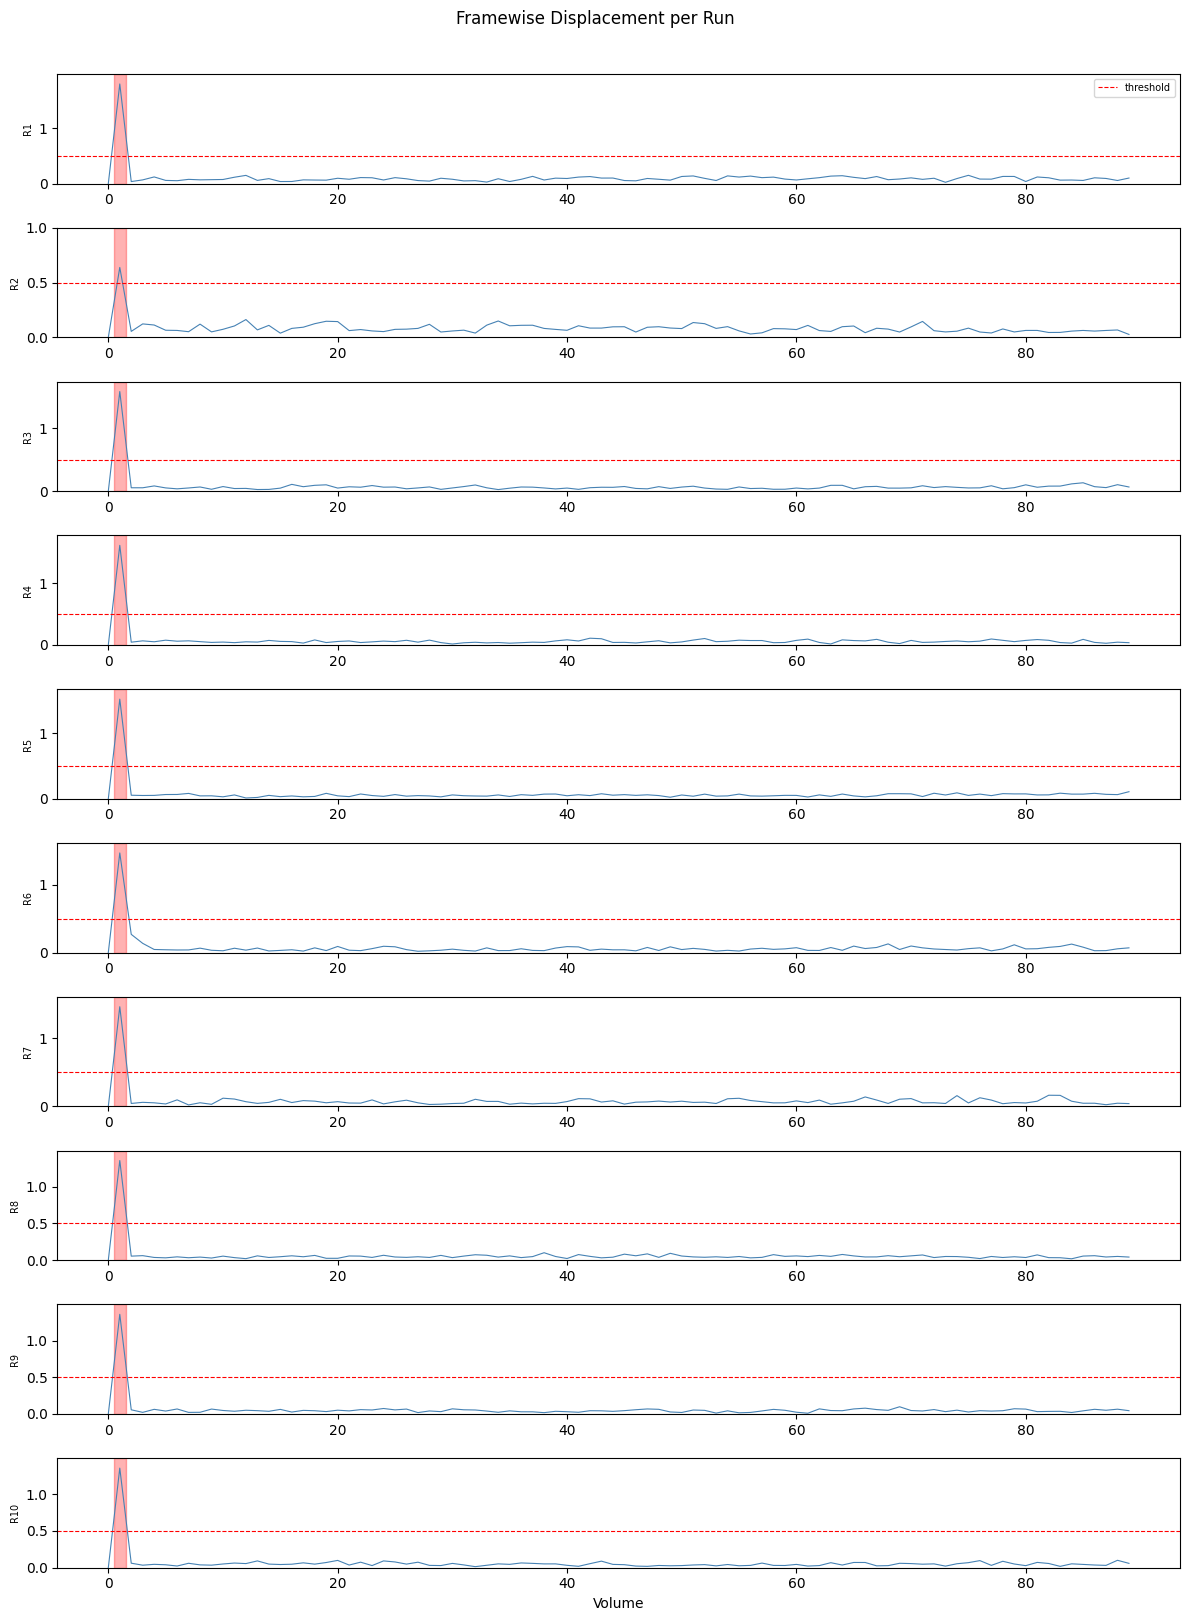

In [9]:
import numpy as np
import pandas as pd

def build_confounds(motion_all, n_vols=90, n_runs=10, 
                    fd_threshold=0.5, rot_radius=50):
    """
    Build full confound DataFrames from SPM rp_ concatenated motion file.
    
    Parameters
    ----------
    motion_all   : np.ndarray, shape (n_runs * n_vols, 6)
                   SPM realignment params: [tx, ty, tz, rx, ry, rz] in mm/radians
    n_vols       : int, volumes per run
    n_runs       : int, number of runs
    fd_threshold : float, FD spike threshold in mm (default 0.5)
    rot_radius   : float, radius (mm) for rotation->mm conversion (default 50)
    
    Returns
    -------
    confounds_list : list of pd.DataFrame, one per run
    fd_list        : list of pd.Series, FD trace per run (for QC plotting)
    """
    
    # Sanity check
    assert motion_all.shape[0] == n_runs * n_vols, (
        f"Expected {n_runs * n_vols} rows, got {motion_all.shape[0]}. "
        "Were runs realigned separately?"
    )
    assert motion_all[:, 3:].max() < 0.2, (
        "Rotations look large — are they in degrees not radians?"
    )

    confounds_list = []
    fd_list = []

    for run in range(n_runs):
        start = run * n_vols
        end = (run + 1) * n_vols
        mp = motion_all[start:end, :]

        # ── 1. Raw 6 parameters ──────────────────────────────────────────────
        df_raw = pd.DataFrame(mp, columns=[
            'trans_x', 'trans_y', 'trans_z',
            'rot_x',   'rot_y',   'rot_z'
        ])

        # ── 2. Derivatives (backward diff, first TR = 0) ─────────────────────
        df_deriv = df_raw.diff().fillna(0)
        df_deriv.columns = [f'{c}_derivative1' for c in df_raw.columns]

        # ── 3. Framewise displacement ─────────────────────────────────────────
        # Convert rotations to mm arc-length before summing
        mp_mm = df_raw.copy()
        for col in ['rot_x', 'rot_y', 'rot_z']:
            mp_mm[col] = mp_mm[col] * rot_radius
        fd = mp_mm.diff().abs().sum(axis=1).fillna(0)
        fd.name = 'framewise_displacement'
        fd_list.append(fd)

        # ── 4. Spike regressors (one column per outlier volume) ───────────────
        spike_idx = fd[fd > fd_threshold].index.tolist()
        spike_df = pd.DataFrame(index=df_raw.index)
        for t in spike_idx:
            col = np.zeros(n_vols, dtype=int)
            col[t] = 1
            spike_df[f'spike_{t:03d}'] = col

        n_spikes = len(spike_idx)
        pct = 100 * n_spikes / n_vols
        status = "⚠️ HIGH" if pct > 15 else "✓"
        print(f"Run {run+1:02d}: {n_spikes:2d} spikes ({pct:.1f}% of TRs)  "
              f"FD max={fd.max():.3f}mm mean={fd.mean():.3f}mm  {status}")

        # ── 5. Concatenate all confounds ──────────────────────────────────────
        parts = [df_raw, df_deriv]
        if not spike_df.empty:
            parts.append(spike_df)
        
        confounds_list.append(pd.concat(parts, axis=1))

    total_spikes = sum(len(fd[fd > fd_threshold]) for fd in fd_list)
    print(f"\nTotal: {total_spikes} spike regressors across {n_runs} runs")
    print(f"Confound matrix shape per run: {confounds_list[0].shape} "
          f"(+spikes vary)")

    return confounds_list, fd_list
confounds_list, fd_list = build_confounds(
    motion_all, 
    n_vols=90, 
    n_runs=10,
    fd_threshold=0.5,
)

# Quick FD plot across all runs
import matplotlib.pyplot as plt

fig, axes = plt.subplots(10, 1, figsize=(12, 16), sharex=False)
for i, (fd, ax) in enumerate(zip(fd_list, axes)):
    ax.plot(fd.values, lw=0.8, color='steelblue')
    ax.axhline(0.5, color='red', lw=0.8, ls='--', label='threshold')
    ax.set_ylabel(f'R{i+1}', fontsize=7)
    ax.set_ylim(0, max(1.0, fd.max() * 1.1))
    # Shade spike TRs
    for t in fd[fd > 0.5].index:
        ax.axvspan(t - 0.5, t + 0.5, color='red', alpha=0.3)

axes[0].legend(fontsize=7)
axes[-1].set_xlabel('Volume')
fig.suptitle('Framewise Displacement per Run', y=1.01)
plt.tight_layout()
plt.savefig('fd_qc.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
for i,m in enumerate(confounds_list):
    print(f"Run {i+1}: {m.shape[0]} timepoints")

Run 1: 90 timepoints
Run 2: 90 timepoints
Run 3: 90 timepoints
Run 4: 90 timepoints
Run 5: 90 timepoints
Run 6: 90 timepoints
Run 7: 90 timepoints
Run 8: 90 timepoints
Run 9: 90 timepoints
Run 10: 90 timepoints


In [63]:

# movfiles = [opj(moco_folder,f) for f in rfiles_ if (f.endswith('pt45.mat') ) ]
# movfiles.sort()
# movfiles = movfiles[1::] # exclude first run for now...
# from scipy.spatial.transform import Rotation
# confounds_ind = []
# for tm in movfiles:
#     affines = sio.loadmat(tm)['mat']
#     n_timepoints = affines.shape[2]
#     motion_params = np.zeros((n_timepoints, 6))

#     for i in range(n_timepoints):
#         affine = affines[:, :, i]
        
#         # Extract translations (in mm)
#         motion_params[i, 0:3] = affine[0:3, 3]
        
#         # Extract rotations (convert to radians)
#         rotation_matrix = affine[0:3, 0:3]
#         r = Rotation.from_matrix(rotation_matrix)
#         motion_params[i, 3:6] = r.as_euler('xyz', degrees=False)

#     confounds_ind.append(pd.DataFrame(motion_params,
#                             columns=['trans_x', 'trans_y', 'trans_z',
#                                     'rot_x', 'rot_y', 'rot_z']))


In [11]:
rfiles.sort()
for r in rfiles:
    print(r)

/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-01_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-02_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-03_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-04_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-05_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-06_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-07_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-08_bold.nii
/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_

In [12]:
dm_file = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/logfiles/col_dm_cond.mat'
tdm_mat = sio.loadmat(dm_file)
tn_trs = 90 # 90 timepts
t_tr = 3 #
dur = 30

dm_conds = [str(i[0]) for i in tdm_mat['names'][0]]
ons = {}
dur = {}
cond_list = []
for iC,c in enumerate(dm_conds):
    ons[c] = tdm_mat['onsets'][0][iC][0] # weird matlab... have to index this way
    if c != 'rest':
        cond_list.append(c)
print(ons['rest'])
print(ons['colour'])
print(ons['bw'])

conditions = ['col', 'bw', 'bw', 'col', 'col', 'bw', 'bw', 'col']
duration =   [30] * len(conditions)
onsets = [15, 45, 75, 105, 135, 165, 195, 225, ]

[8.45125000e-04 2.55008815e+02]
[ 15.01033804 105.00170842 135.01069308 225.01644929]
[ 45.00162958  75.01012975 165.00254796 195.00816542]


In [13]:
# https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_design_matrix.html#sphx-glr-auto-examples-04-glm-first-level-plot-design-matrix-py
from nilearn.plotting import plot_design_matrix
t_r = 3
n_scans = 90
frame_times = (np.arange(n_scans) * t_r) # Corresponding frame times

# Next, we simulate 6 motion parameters jointly observed with fMRI acquisitions
# rng = np.random.default_rng(42)
# motion = np.cumsum(rng.standard_normal((n_scans, 6)), 0)
# # The 6 parameters correspond to three translations and three
# # rotations describing rigid body motion
# add_reg_names = ["tx", "ty", "tz", "rx", "ry", "rz"]

In [14]:
import pandas as pd

events = pd.DataFrame(
    {"trial_type": conditions, "onset": onsets, "duration": duration}
)


from nilearn.glm.first_level import make_first_level_design_matrix

# hrf_model = "glover"
# X1 = make_first_level_design_matrix(
#     frame_times,
#     events,
#     drift_model="polynomial",
#     drift_order=1,
#     high_pass=0.01,
#     add_regs=confounds_list[0],
#     # add_reg_names=add_reg_names,
#     hrf_model=hrf_model,
# )
# plot_design_matrix(X1)

In [ ]:
# rfiles_ = []
# for i,r in enumerate(rdata):
#     print(r.shape)
#     if r.shape[-1]==90:
#         rfiles_.append(opj(moco_folder, rfiles[i]))

(328, 328, 99, 90)


#### 2 level

In [16]:
# https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_write_events_file.html#sphx-glr-auto-examples-04-glm-first-level-plot-write-events-file-py

fmri_glms = []
for i in range(len(rfiles)):
    subject_data = rfiles[i]
    from nilearn.glm.first_level import FirstLevelModel
    tglm = FirstLevelModel()
    tdm = make_first_level_design_matrix(
        frame_times,
        events,
        drift_model="polynomial",
        drift_order=1,
        # high_pass=0.01,
        # add_regs=confounds_list[i],
        # add_reg_names=add_reg_names,
        hrf_model="spm",
    )
    fmri_glms.append(
        tglm.fit(subject_data, design_matrices=tdm)
    )



/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_60706/3526168655.py:19: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  tglm.fit(subject_data, design_matrices=tdm)


KeyboardInterrupt: 

In [16]:
contrast_name = 'col - bw'
run_images = []

for g in fmri_glms:
    # We take the 'effect_size' (equivalent to FSL's COPE) 
    # for the second level input
    eff_map = g.compute_contrast(contrast_name, output_type='effect_size')
    run_images.append(eff_map)

In [ ]:
from nilearn.glm.second_level import SecondLevelModel
import pandas as pd
import numpy as np

# 1. Create a design matrix for a one-sample test (the mean of the runs)
design_matrix = pd.DataFrame([1] * len(run_images), columns=['intercept'])

# 2. Initialize the Second Level Model
# smoothing_fwhm is often set to None here if you already smoothed at the first level
second_level_model = SecondLevelModel(smoothing_fwhm=None)

# 3. Fit the model using the list of images
second_level_model.fit(run_images, design_matrix=design_matrix)

# 4. Compute the final 'Subject-Level' map
# This is your "Fixed Effects" result across all runs
z_map = second_level_model.compute_contrast(output_type='z_score')
p_map = second_level_model.compute_contrast(output_type='p_value')

r10dir = opj(stest_dir, 'r10')
if not os.path.exists(r10dir):
    os.makedirs(r10dir)
z_file =  opj(r10dir, 'z10.nii.gz')
zal_file = opj(r10dir, 'z10AL.nii.gz')
subprocess.run('fslreorient2std', )
nib.save(z_map, z_file)
func2anat(z_file, interp='nearest')
import cortex
zdat = nib.load(zal_file).get_fdata().transpose(2, 1, 0)
zvol = cortex.Volume(zdat, sub, xfmname='identity')
cortex.webshow(zvol,) 

Usage: fslreorient2std [-m <matrix file>] <input_image> [output_image]
 
fslreorient2std is a tool for reorienting the image to match the
approximate orientation of the standard template images (MNI152).
It only applies 0, 90, 180 or 270 degree rotations.
It is not a registration tool.
It requires NIfTI images with valid orientation information
in them (seen by valid labels in FSLView).  This tool
assumes the labels are correct - if not, fix that before using this.
If the output name is not specified the equivalent transformation
 matrix is written to the standard output
If the option -m is given, with an accompanying filename, then the
 transformation matrix is written to this file instead
 
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-L003/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/r10/z10.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/deri

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/r10/z10.nii.gz /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-L003/mri/brain.mgz
movvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/r10/z10.nii.gz
targvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-L003/mri/brain.mgz
outvol /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/r10/z10AL.nii.gz
regfile /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-L003/tmp.lta
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  nearest (0)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1773039790

Final tkRAS-to-tkRAS Matrix is:
 0.98957   0.00084   0.00051   0.76070;
-0.00121   0.29957   0.93999  -1.95075;
 0.00110  -0.94061   0.29772  -73.57139;
 0.00000   0.00000   0.00000   1.00000;


Vox2Vox Matrix is:
 0

In [21]:
import cortex
zdat = nib.load(zal_file).get_fdata().transpose(2, 1, 0)
zvol = cortex.Volume(zdat, sub, xfmname='identity')
cortex.webshow(zvol,) 

Generating new ctm file...
wm
wm
inflated
inflated
Started server on port 3857


<JS: window.viewer>

In [ ]:
cortex.freesurfer.import_subj(
    'sub-L003', 
    pycortex_subject='sub-L003', 
    freesurfer_subject_dir='/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer', 
    )

AttributeError: 

# trying all in one 

In [54]:
from nilearn.glm.first_level import FirstLevelModel

glm = FirstLevelModel(
    t_r=3.0,
    hrf_model='spm',
    drift_model='cosine',   # DCT basis
    high_pass=1/128,        # standard 128s cutoff
    noise_model='ar1',
    standardize=False,      # don't standardize — preserve effect sizes
)


events_list = [events]*len(rfiles)

# nilearn accepts lists directly - same events for each run, different confounds
glm.fit(rfiles, events=events_list, confounds=confounds_list)

/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2971827939.py:16: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(rfiles, events=events_list, confounds=confounds_list)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2971827939.py:16: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(rfiles, events=events_list, confounds=confounds_list)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2971827939.py:16: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(rfiles, events=events_list, confounds=confounds_list)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2971827939.py:16: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(rfiles, ev

,t_r,3.0
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.0078125
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [55]:
z_map = glm.compute_contrast('col - bw', output_type='z_score')
e_map = glm.compute_contrast('col - bw', output_type='effect_size')
r10dir = opj(stest_dir, 'r10')
if not os.path.exists(r10dir):
    os.makedirs(r10dir)
z_file =  opj(r10dir, 'z10.nii.gz')
zal_file = opj(r10dir, 'z10al.nii.gz')
nib.save(z_map, z_file)
func2anat(z_file, interp='trilin')


e_file =  opj(r10dir, 'e10.nii.gz')
eal_file = opj(r10dir, 'e10al.nii.gz')
nib.save(e_map, e_file)
func2anat(e_file, interp='trilin')


/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/1607269059.py:1: RuntimeWarning: The same contrast will be used for all 10 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = glm.compute_contrast('col - bw', output_type='z_score')
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/1607269059.py:2: RuntimeWarning: The same contrast will be used for all 10 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  e_map = glm.compute_contrast('col - bw', output_type='effect_size')


target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/r10/z10.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.000

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/r10/e10.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registratio

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done


In [18]:

import cortex
zdat = nib.load(zal_file).get_fdata().transpose(2, 1, 0)
zvol = cortex.Volume(zdat, sub, xfmname='identity', )
cortex.webshow(zvol,) 

Started server on port 36021


KeyboardInterrupt: 

### all in one - 2 split

In [19]:
# from nilearn.glm.first_level import FirstLevelModel
# split_i = 5
# zvols = {}
# for split in [1,2]:
#     glm = FirstLevelModel(
#         t_r=3.0,
#         hrf_model='spm',
#         drift_model='cosine',
#         high_pass=1/128,
#         noise_model='ols',
#     )
#     if split == 1:
#         trfiles = rfiles[:split_i]
#         tconf = confounds_list[:split_i]
#     else:
#         trfiles = rfiles[split_i:]
#         tconf = confounds_list[split_i:]
#     events_list = [events]*len(trfiles)

#     # nilearn accepts lists directly - same events for each run, different confounds
#     glm.fit(trfiles, events=events_list,confounds=tconf)
#     z_map = glm.compute_contrast('col - bw', output_type='z_score')
#     rSPLITdir = opj(stest_dir, 'rSPLIT')
#     if not os.path.exists(rSPLITdir):
#         os.makedirs(rSPLITdir)
#     z_file =  opj(rSPLITdir, f'z{split}.nii.gz')
#     zal_file = opj(rSPLITdir, f'z{split}al.nii.gz')
#     nib.save(z_map, z_file)
#     func2anat(z_file, interp='trilinear')
#     zdat = nib.load(zal_file).get_fdata().transpose(2, 1, 0)
#     zvols[f's{split}'] = cortex.Volume(zdat, sub, xfmname='identity')


In [20]:
from nilearn.glm.first_level import FirstLevelModel
import numpy as np
import nibabel as nib
import os
from os.path import join as opj

run_indices = np.arange(len(rfiles))
splits = {
    1: run_indices[::2],   # interleaved: even runs
    2: run_indices[1::2],  # interleaved: odd runs
}

zvols = {}
effect_vols = {}
rSPLITdir = opj(stest_dir, 'rSPLIT')
if os.path.exists(rSPLITdir):
    shutil.rmtree(rSPLITdir)
for split, idx in splits.items():
    trfiles_split = [rfiles[i] for i in idx]
    tconf_split = [confounds_list[i] for i in idx]
    events_split = [events] * len(trfiles_split)

    glm = FirstLevelModel(
        t_r=3.0,
        hrf_model='spm',
        drift_model='cosine',   # DCT basis
        high_pass=1/128,        # standard 128s cutoff
        noise_model='ar1',
        standardize=False,      # don't standardize — preserve effect sizes
    )

    glm.fit(trfiles_split, events=events_split, confounds=tconf_split)

    z_map = glm.compute_contrast('col - bw', output_type='z_score')
    effect_map = glm.compute_contrast('col - bw', output_type='effect_size')


    os.makedirs(rSPLITdir, exist_ok=True)

    z_file = opj(rSPLITdir, f'z{split}.nii.gz')
    eff_file = opj(rSPLITdir, f'effect{split}.nii.gz')
    nib.save(z_map, z_file)
    nib.save(effect_map, eff_file)

    func2anat(z_file, interp='trilin')
    zal_file = opj(rSPLITdir, f'z{split}al.nii.gz')
    zdat = nib.load(zal_file).get_fdata().transpose(2, 1, 0)
    zvols[f'z{split}'] = cortex.Volume(zdat, sub, xfmname='identity')
    
    func2anat(eff_file, interp='trilin')
    effal_file = opj(rSPLITdir, f'effect{split}al.nii.gz')
    edat = nib.load(effal_file).get_fdata().transpose(2, 1, 0)
    effect_vols[f'e{split}'] = cortex.Volume(edat, sub, xfmname='identity')


/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(trfiles_split, events=events_split, confounds=tconf_split)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(trfiles_split, events=events_split, confounds=tconf_split)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(trfiles_split, events=events_split, confounds=tconf_split)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/rSPLIT/z1.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.0

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/rSPLIT/effect1.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final regi

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done


/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(trfiles_split, events=events_split, confounds=tconf_split)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(trfiles_split, events=events_split, confounds=tconf_split)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:32: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm.fit(trfiles_split, events=events_split, confounds=tconf_split)
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_49018/2864119464.py:34: RuntimeWarning: The same contrast will be used for all 5 runs. If the design matrices are not the same for all runs, (f

target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/rSPLIT/z2.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final registration.
Ttarg: --------------------
-1.00000   0.00000   0.00000   128.0

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done
target  volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
movable volume /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/rSPLIT/effect2.nii.gz
reg file       /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/bbreg.dat
LoadVol        0
ZeroCRAS       0
dev
Diagnostic Level -1
---- Input registration matrix --------
 0.99825   0.00309  -0.00045   0.99461;
-0.00258   0.31123   0.96658  -1.77859;
 0.00326  -0.96114   0.31212  -75.13107;
 0.00000   0.00000   0.00000   1.00000;
float2int = 0
---------------------------------------
INFO: loading target /Users/marcusdaghlian/projects/pilot-clean-link/derivatives/freesurfer/sub-03_prefprepBU/mri/brain.mgz
INFO: target does not conform to COR format, so I'm going to
reslice to COR. This will not affect the final regi

INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)
INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done


In [33]:
from dpu_mini.utils import *
def load_benson14_info(sub, fs_dir):
    ''' *no*
    '''
    sub_fs_dir = opj(fs_dir, sub, 'surf')    
    b14_dict = {}
    for p in ['eccen', 'angle', 'sigma', 'varea']:
        hemi_p = []
        for hemi in ['lh', 'rh']:
            b14_p_file = dag_find_file_in_folder(
                [hemi, p, 'benson14', '.mgz'],
                sub_fs_dir,
            )
            hemi_p.append(nib.load(b14_p_file).get_fdata().squeeze())   
        if p=='eccen':
            better_name = 'ecc'
        elif p=='angle':
            better_name = 'pol'
        elif p=='sigma':
            better_name = 'size_1'
        elif p=='varea':
            better_name = 'varea'
        b14_dict[better_name] = np.concatenate(hemi_p, axis=0)
    return b14_dict
b14_info = load_benson14_info(sub, fs_dir)

In [45]:
from scipy.stats import pearsonr
import numpy as np

# Within a V2 ROI mask
roi_mask = nib.load(b14_v2_dil).get_fdata().astype(bool).transpose(2,1,0)

z1 = nib.load(opj(rSPLITdir, f'z1al.nii.gz')).get_fdata().transpose(2,1,0)
z2 = nib.load(opj(rSPLITdir, f'z2al.nii.gz')).get_fdata().transpose(2,1,0)
e1 = nib.load(opj(rSPLITdir, f'effect1al.nii.gz')).get_fdata().transpose(2,1,0)
e2 = nib.load(opj(rSPLITdir, f'effect2al.nii.gz')).get_fdata().transpose(2,1,0)
r_valz, _ = pearsonr(z1[roi_mask], z2[roi_mask])
r_vale, _ = pearsonr(e1[roi_mask], e2[roi_mask])

# Spearman-Brown correction for full-sample reliability estimate

print(f'Split-half (z) r = {r_valz:.3f}, ')
print(f'Split-half (eff) r = {r_vale:.3f}, ')

Split-half (z) r = 0.537, 
Split-half (eff) r = 0.681, 


In [ ]:
maps = {}
maps['z1'] = nib.load(opj(rSPLITdir, f'z1al.nii.gz')).get_fdata().transpose(2,1,0)
maps['z2'] = nib.load(opj(rSPLITdir, f'z2al.nii.gz')).get_fdata().transpose(2,1,0)
maps['e1'] = nib.load(opj(rSPLITdir, f'effect1al.nii.gz')).get_fdata().transpose(2,1,0)
maps['e2'] = nib.load(opj(rSPLITdir, f'effect2al.nii.gz')).get_fdata().transpose(2,1,0)
maps['z10'] = nib.load(opj(r10dir, 'z10al.nii.gz')).get_fdata().transpose(2,1,0)
maps['e10'] = nib.load(opj(r10dir, 'e10al.nii.gz')).get_fdata().transpose(2,1,0)
maps['tsnr'] = nib.load(opj(stest_dir, f'runtsnral.nii.gz')).get_fdata().transpose(2,1,0)
# Voxelwise reliability: geometric mean preserving sign
# sign_agree = np.sign(z1) == np.sign(z2)

# reli_z = np.where(
#     sign_agree,
#     np.sign(z1) * np.minimum(np.abs(z1), np.abs(z2)),  # limited by weaker half
#     0  # hard zero where halves disagree
# )


vols = {}
for m in maps.keys():
    if m != 'tsnr':        
        vols[m] = cortex.Volume(
            maps[m], sub, xfmname='identity',
            vmin=-3, vmax=3,
            cmap='RdBu_r'
        )
    else:
        vols[m] = cortex.Volume(
            maps[m], sub, xfmname='identity',
            # vmin=-3, vmax=3,
            # cmap='RdBu_r'
        )

vols['reli_z'] = cortex.Volume(
    reli_z, sub, xfmname='identity',
    vmin=-3, vmax=3,
    cmap='RdBu_r'
)


In [47]:
vols['b14ecc']= cortex.Vertex(
    b14_info['ecc'], sub, 
    cmap='jet', vmin=0, vmax=10, 
)
vols['b14pol']= cortex.Vertex(
    b14_info['pol'], sub, 
    cmap='hsv', vmin=0, vmax=180, 
)


In [48]:

cortex.webshow(vols, with_rois=True)

Stopping server
Started server on port 65198
Stopping server


<JS: window.viewer>

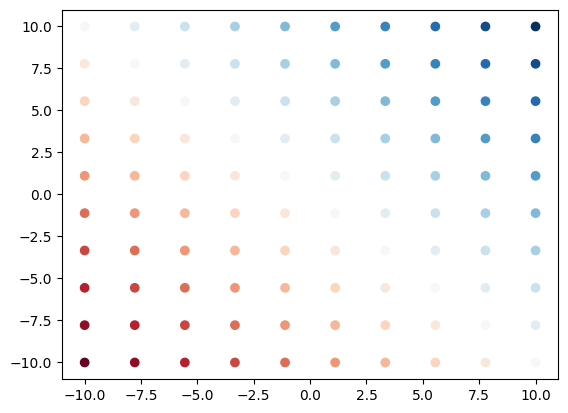

In [53]:
a = np.linspace(-10,10,10)
ma1,ma2 = np.meshgrid(a,a)
rel = np.sign(ma1 * ma2) * np.sqrt(np.abs(ma1 * ma2))
rel = (ma1 + ma2) / 2
# plt.imshow(rel, cmap='RdBu', vmin=-10, vmax=10)
plt.scatter(
    ma1.flatten(), ma2.flatten(), c=rel.flatten(), 
    vmin=-10, vmax=10, cmap='RdBu'
)
# plt.imshow(ma2-ma1)

In [100]:
b14_vol_dil

'/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03_prefprepBU/b14_vol2.nii.gz'

In [ ]:
import brainsmash

In [56]:
cortex.webshow(data=zvols)

TypeError: keywords must be strings

In [53]:
zal_file

'/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/a_glm_test_s03_nilearn/sub-03/r10/z10AL1.nii.gz'

In [49]:
rfiles

['/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-01_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-02_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-03_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-04_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-05_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-06_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-07_bold.nii',
 '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/spm_align/sub-03/rsub-03_task-task-colbw_run-08_bold.nii',
 '/Users/marcusdaghlian/projects

In [43]:
len(confounds_list)

5

In [41]:
eff_map

# fter

/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_39816/3305234390.py:3: RuntimeWarning: The same contrast will be used for all 9 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  bw_beta = fmri_glm.compute_contrast('bw', output_type='effect_size')
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_39816/3305234390.py:4: RuntimeWarning: The same contrast will be used for all 9 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  col_beta = fmri_glm.compute_contrast('col', output_type='effect_size')
/var/folders/01/hhsk37310zsgzgg1nhgs6rfm0000gn/T/ipykernel_39816/3305234390.py:7: RuntimeW

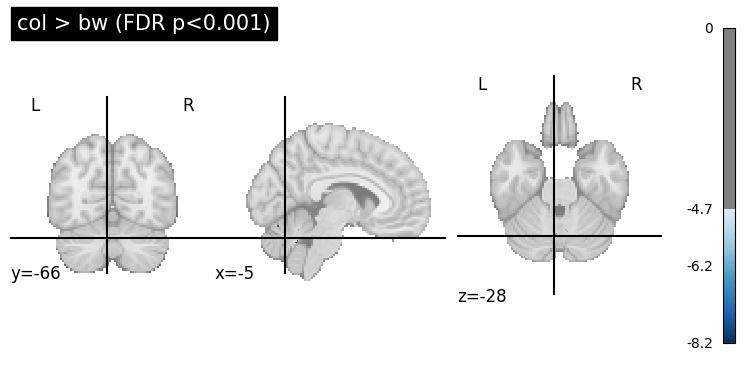

In [42]:

# 3. Compute contrasts
# For betas of each condition:
bw_beta = fmri_glm.compute_contrast('bw', output_type='effect_size')
col_beta = fmri_glm.compute_contrast('col', output_type='effect_size')

# For the difference (col - bw):
contrast = fmri_glm.compute_contrast('col - bw', output_type='stat')
z_map = fmri_glm.compute_contrast('col - bw', output_type='z_score')

# 4. Threshold for significance
from nilearn.glm import threshold_stats_img

thresholded_map, threshold = threshold_stats_img(
    z_map, 
    alpha=0.001, 
    height_control='fdr',  # or 'bonferroni', 'fpr'
    cluster_threshold=10
)

# 5. Visualize
plot_stat_map(thresholded_map, threshold=threshold, 
              title='col > bw (FDR p<0.001)')

In [76]:
bw_beta

# split half 

In [108]:
from nilearn.glm.second_level import SecondLevelModel
import pandas as pd
import numpy as np
import cortex
runs = {
    '1' : np.arange(0,9,2),
    '2' : np.arange(1,9,2)
}
al_path = "/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03"
nii_brain = opj(al_path, 'brain.nii')
reg_mat = opj(al_path, 'bbregV1.mat')
reg_dat = opj(al_path, 'bbregV1.dat')
z_maps = {}
p_maps = {}
ctx_vols = {}
for k in runs.keys():
    # 1. Create a design matrix for a one-sample test (the mean of the runs)
    design_matrix = pd.DataFrame([1] * len(runs[k]), columns=['intercept'])

    # 2. Initialize the Second Level Model
    # smoothing_fwhm is often set to None here if you already smoothed at the first level
    second_level_model = SecondLevelModel(smoothing_fwhm=None)
    truns = [run_images[i] for i in runs[k]]
    # 3. Fit the model using the list of images
    second_level_model.fit(truns, design_matrix=design_matrix)

    # 4. Compute the final 'Subject-Level' map
    # This is your "Fixed Effects" result across all runs
    z_maps[k] = second_level_model.compute_contrast(output_type='z_score')
    p_maps[k] = second_level_model.compute_contrast(output_type='p_value')
    tth = p_maps[k].get_fdata()>0.95
    tzmap_data = z_maps[k].get_fdata() * tth
    tzmap_nii = nib.Nifti1Image(tzmap_data, z_maps[k].affine, z_maps[k].header)
    alm_path = opj(al_path, 'test')
    # if os.path.exists(alm_path):
    #     os.unlink(alm_path)
    # os.makedirs(alm_path)
    ppath = opj(alm_path, f'p{k}.nii.gz')
    ppathAL = opj(alm_path, f'p{k}AL.nii.gz')
    nib.save(p_maps[k], ppath)
    cmd = f'mri_vol2vol --mov "{ppath}" --reg '
    cmd += f'"{reg_dat}" --o "{ppathAL}"' 

    # cmd = f'flirt -in "{ppath}" -ref "{nii_brain}" '
    # cmd+= f' -applyxfm -init "{reg_dat}" '
    # cmd+= f'-out  "{ppathAL}"'
    os.system(cmd)
    
    zpath = opj(alm_path, f'z{k}.nii.gz')
    zpathAL = opj(alm_path, f'z{k}AL.nii.gz')
    nib.save(z_maps[k], zpath)
    cmd = f'mri_vol2vol --mov "{zpath}" --reg '
    cmd += f'"{reg_dat}" --o "{zpathAL}"' 
    os.system(cmd)
    

    # tdata = nib.load(ppathAL).get_fdata()
    # ctx_vols[f'p{k}'] = cortex.Volume(tdata, sub, xfmname='identity')
    # tdata = nib.load(zpath).get_fdata()
    # ctx_vols[f'z{k}'] = cortex.Volume(tdata, sub, xfmname='identity')
    # nib.save(tzmap_nii, opj(alm_path, f'z{k}.nii.gz'))
    # bloop


Matrix from regfile:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  -75.39624;
 0.00102  -0.30554  -0.95218   1.66059;
 0.00000   0.00000   0.00000   1.00000;

INFO: This REGISTER_DAT transform is valid only for volumes between  COR types with c_(r,a,s) = 0.
Getting target volume geom from lta destination
movvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/p1.nii.gz
outvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/p1AL.nii.gz
regfile /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/bbregV1.dat
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilinear (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1770817481

Final tkRAS-to-tkRAS Matrix is:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  -75.39624;
 0.00102  -0.30554  -0.95218   1.66059;
 0.00000   0.00000

INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done

Matrix from regfile:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  -75.39624;
 0.00102  -0.30554  -0.95218   1.66059;
 0.00000   0.00000   0.00000   1.00000;

INFO: This REGISTER_DAT transform is valid only for volumes between  COR types with c_(r,a,s) = 0.
Getting target volume geom from lta destination
movvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/z1.nii.gz
outvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/z1AL.nii.gz
regfile /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/bbregV1.dat
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilinear (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1770969765

Final tkRAS-to-tkRAS Matrix is:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  

INFO: using NIfTI-1 sform (sform_code=2)



Resampling
Output registration matrix is identity

mri_vol2vol done

Matrix from regfile:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  -75.39624;
 0.00102  -0.30554  -0.95218   1.66059;
 0.00000   0.00000   0.00000   1.00000;

INFO: This REGISTER_DAT transform is valid only for volumes between  COR types with c_(r,a,s) = 0.
Getting target volume geom from lta destination
movvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/p2.nii.gz
outvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/p2AL.nii.gz
regfile /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/bbregV1.dat
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilinear (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1771037690

Final tkRAS-to-tkRAS Matrix is:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  

INFO: using NIfTI-1 sform (sform_code=2)



Matrix from regfile:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  -75.39624;
 0.00102  -0.30554  -0.95218   1.66059;
 0.00000   0.00000   0.00000   1.00000;

INFO: This REGISTER_DAT transform is valid only for volumes between  COR types with c_(r,a,s) = 0.
Getting target volume geom from lta destination
movvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/z2.nii.gz
outvol /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/test/z2AL.nii.gz
regfile /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/align_testing/sub-03/bbregV1.dat
invert 0
tal    0
talres 2
regheader 0
noresample 0
interp  trilinear (1)
precision  float (3)
Gdiag_no  -1
Synth      0
SynthSeed  1771251512

Final tkRAS-to-tkRAS Matrix is:
 0.99999   0.00417  -0.00026   0.85669;
 0.00405  -0.95217   0.30554  -75.39624;
 0.00102  -0.30554  -0.95218   1.66059;
 0.00000   0.00000

INFO: using NIfTI-1 sform (sform_code=2)


In [89]:
tdata = nib.load(opj(alm_path, 'z1.nii.gz')).get_fdata()
a = cortex.Volume(tdata, sub, xfmname='identity')

ValueError: Volumetric data (shape (328, 328, 99)) is not the same shape as reference for transform (shape (340, 340, 340))

In [87]:
cortex.webshow(a,) 

Started server on port 60723
Stopping server
Stopping server


<JS: window.viewer>

In [ ]:
v2 = cortex.Volume(data, subject='sub-03', xfmname='identity')
data = {'v1': v1, 'v2': v2}
cortex.webshow(data,) #recache=True)

In [42]:
p_maps[k].get_fdata().max()

np.float64(0.9999999746885647)

In [88]:
a.shape

(340, 340, 340)

In [26]:
tth

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

array([1, 3, 5, 7])

In [11]:
nib.save(z_map, 'colmbw10runs_zmap.nii')
nib.save(p_map, 'colmbw10runs_map.nii')

In [42]:
tglm = FirstLevelModel()
fmri_glms = [tglm.fit(rfiles, design_matrices=[X1, X1, X1])]

In [13]:
colgtbw = tglm.compute_contrast('col > bw', output_type='z_score').get_fdata()
colmbw = tglm.compute_contrast('col - bw', output_type='z_score').get_fdata()

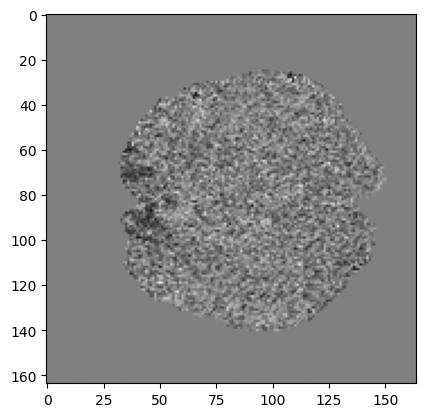

In [19]:
plt.imshow(colmbw[:, :, -30], cmap='gray', vmin=-5, vmax=5)

In [9]:
# https://nilearn.github.io/dev/auto_examples/04_glm_first_level/plot_write_events_file.html#sphx-glr-auto-examples-04-glm-first-level-plot-write-events-file-py

# Try for average 


subject_data = opj(moco_folder, 'rraverage.nii.gz')
from nilearn.glm.first_level import FirstLevelModel
tglm = FirstLevelModel()
fmri_glms = []
fmri_glms.append(
    tglm.fit(subject_data, design_matrices=X1)
)

In [44]:
tcont = []
for i in range(len(fmri_glms)):
    tcont.append(
        fmri_glms[i].compute_contrast('col > bw').get_fdata())
tcont_mean = np.mean(tcont, axis=0)
# Save as nib
reference_img = fmri_glms[0].compute_contrast('bw > 0') 

new_img = nib.Nifti1Image(
    tcont_mean.astype(np.float32), 
    reference_img.affine, 
    header=reference_img.header # Adding the header is key
)
nib.save(new_img, 'finally10rnns.nii')

In [43]:
len(fmri_glms)

1

In [37]:
fmri_glms[i]

,t_r,None
,slice_time_ref,0.0
,hrf_model,'glover'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


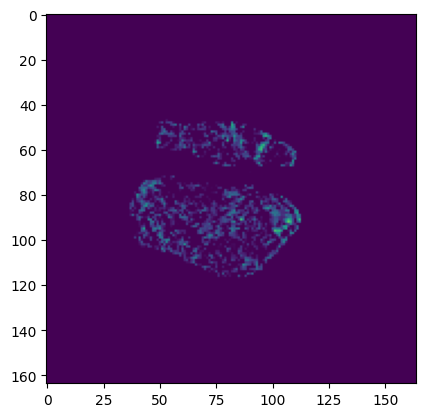

In [52]:
plt.imshow(
    tcont[:,:,-10], 
    vmin=0, vmax=5
)

In [42]:
a = fmri_glm.compute_contrast('bw > 0')
nib.save(a, 'contbwm0.nii')

In [261]:
tdm_mat['onsets'][0][2] 

array([[ 15.01033804, 105.00170842, 135.01069308, 225.01644929]])

In [310]:
import os
opj = os.path.join
moco_folder = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/spm_align/sub-01'
rfiles_ = os.listdir(
    moco_folder
)
rfiles = [opj(moco_folder,f) for f in rfiles_ if f.startswith('rrun')]
rnib = [nib.load(f) for f in rfiles]
rdata = []
for i in range(len(rnib)):
    rdata.append(rnib[i].get_fdata())
# run1_file = 
# r1 = nib.load(run1_file)
# tfunc = r1.get_fdata()

In [311]:
len(rdata)

3

In [150]:
# plt.imshow(tfunc[:,:,-20,0])
# tfsl = tfunc[:,:,-21:-20,:].copy()

In [312]:
import glmsingle
from glmsingle.glmsingle import GLM_single
import scipy
import os
import shutil
opj = os.path.join
# create a directory for saving GLMsingle outputs
deriv_dir = '/Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives'
outputdir_glmsingle = opj(deriv_dir, 'glmsingle', sub, 'test830snohrf')
if not os.path.exists(outputdir_glmsingle):
    os.makedirs(outputdir_glmsingle)
else:
    shutil.rmtree(outputdir_glmsingle)
    os.makedirs(outputdir_glmsingle)

opt = dict()

# set important fields for completeness (but these would be enabled by default)
opt['wantlibrary'] = 0
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 0

# for the purpose of this example we will keep the relevant outputs in memory
# and also save them to the disk
opt['wantfileoutputs'] = [1,1,1,1]
opt['wantmemoryoutputs'] = [1,1,1,1]

# running python GLMsingle involves creating a GLM_single object
# and then running the procedure using the .fit() routine
glmsingle_obj = GLM_single(opt)

# visualize all the hyperparameter

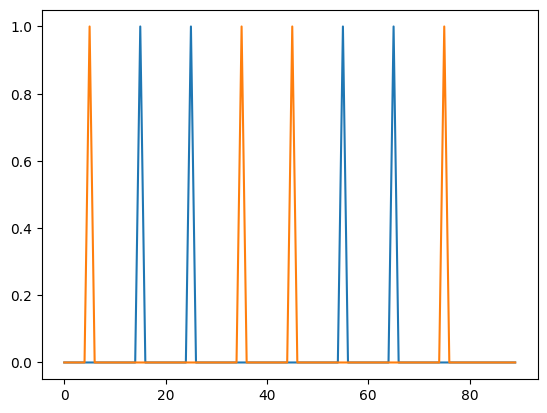

In [269]:
plt.plot(t_dmatrix_info['dmatrix'])
dm1id = np.array([0,3,4,7])
dm2id = np.array([1,2,5,6])

In [313]:
# variables that will contain bold time-series and design matrices from each run
data = []
design = []

nruns = 0
for R in range(len(rdata)):
    data.append(
        rdata[R],
        # tfunc #[:,:,20:21,:]
        )
    design.append(t_dmatrix_info['dmatrix'])
    nruns += 1

# get shape of data volume (XYZ) for convenience
xyz = data[0].shape[:3]
xyzt = data[0].shape

# get total number of blocks - this will be the dimensionality of output betas from GLMsingle
nblocks = int(np.sum(np.concatenate(design)))

# get metadata about stimulus duration and TR
stimdur = 30 # hmm t_dmatrix_info['dur']['bw']
tr = 3.0

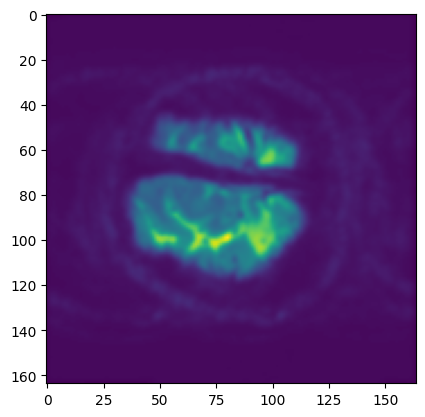

In [301]:
plt.imshow(data[0][:,:,-10,0])

In [297]:
plt.imshow(data[0][:,:,-10,10]) #- data[1][:,:,0,1])

IndexError: too many indices for array: array is 3-dimensional, but 4 were indexed

In [314]:
# run GLMsingle
results_glmsingle = glmsingle_obj.fit(
   design,
   data,
   stimdur,
   tr,
   outputdir=outputdir_glmsingle)

*** DIAGNOSTICS ***:
There are 3 runs.
The number of conditions in this experiment is 2.
The stimulus duration corresponding to each trial is 30.00 seconds.
The TR (time between successive data points) is 3.00 seconds.
The number of trials in each run is: [8, 8, 8].
The number of trials for each condition is: [np.int64(12), np.int64(12)].
For each condition, the number of runs in which it appears: [np.int64(3), np.int64(3)].
For each run, how much ending buffer do we have in seconds? [np.float64(42.0), np.float64(42.0), np.float64(42.0)].
*** Saving design-related results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/RUNWISEFIR.npy. ***

*** FITTING TYPE-A MODEL (ONOFF) ***

fitting model...
done.

preparing output...
done.

comp

/Users/marcusdaghlian/miniforge3/envs/glms001/lib/python3.14/site-packages/sklearn/mixture/_base.py:293: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


*** Setting brain R2 threshold to 0.5259465739237177 ***

*** FITTING TYPE-B MODEL (FITHRF) ***



chunks: 100%|██████████| 24/24 [00:06<00:00,  3.73it/s]



*** Saving results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/TYPEB_FITHRF.npy. ***

*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 24/24 [00:52<00:00,  2.19s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 24/24 [00:17<00:00,  1.36it/s]


*** Saving results to /Users/marcusdaghlian/CVL Dropbox/Marcus  Daghlian/pilot-clean/derivatives/glmsingle/sub-01/test830snohrf/TYPEC_FITHRF_GLMDENOISE.npy. ***

*** All model types done ***

*** return model types in results ***



In [315]:
# Get m
meanvol = np.squeeze(np.mean(data[0].reshape(xyzt),3))
r2_th = results_glmsingle['typeb']['R2']>20
brainmask = meanvol > 2500
beta_id = {
    'bw' : [0,3,4,7],
    'col':[1,2,5,6],
}
betas = {}
for k in beta_id.keys():
    betas[k] = []
    for i in beta_id[k]:
        betas[k].append(results_glmsingle['typec']['betasmd'][:,:,:,i])
    betas[k] = np.mean(betas[k], axis=0)

bth = betas.copy()
for k in bth.keys():
    
    bth[k][~brainmask] = np.nan
    bth[k][~r2_th] = np.nan


In [322]:
ball=(bth['col']+bth['bw'])/2
ball=results_glmsingle['typea']['onoffR2']
ball

array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[           nan, 1.00662245e-01, 2.17699017e-01, ...,
                    nan,            nan,            nan],
        [           nan, 2.01462661e-01, 1.15008030e-01, ...,
                    nan,            nan,            nan],
        [           nan, 

In [247]:
np.nanmax(results_glmsingle['typeb']['R2'])

np.float32(45.367443)

In [323]:
# ball = results_glmsingle['typeb']['R2']
ball_img = nib.Nifti1Image(ball.astype(np.float32), rnib[0].affine)
nib.save(ball_img, 'blahonoff.nii')


# nilearn denoising

In [9]:
from nilearn.interfaces.fmriprep import load_confounds_strategy
from nilearn.maskers import NiftiMasker
import os
opj = os.path.join
# 1. Define paths to your fMRIPrep outputs
fmriprep_path = '/Users/marcusdaghlian/projects/pilot-clean-link/derivatives/BIDS/derivatives/fmriprep/sub-01/ses-1/func'
bold_files_ = os.listdir(fmriprep_path)
bold_files = [opj(fmriprep_path,b) for b in bold_files_ if 'preproc_bold.nii' in b]
img_paths = bold_files

In [10]:




# 2. Load PCA-based confounds (CompCor)
# This selects 5 anatomical CompCor components (PCA) + motion parameters
confounds, sample_mask = load_confounds_strategy(
    img_paths, 
    denoise_strategy="compcor", 
    n_compcor=5
)


In [ ]:

# 3. Apply denoising using a Masker
masker = NiftiMasker(
    standardize=True, 
    smoothing_fwhm=0, 
    detrend=True, 
    low_pass=0.08, 
    high_pass=0.01, 
    t_r=3.0
)

# This step performs the actual regression of the PCA components
denoised_data = masker.fit_transform(img_paths, confounds=confounds, sample_mask=sample_mask)


In [ ]:

# (Optional) Reconstruct into a 4D Nifti if needed
denoised_img = masker.inverse_transform(denoised_data)
denoised_img.to_filename('sub-01_denoised_PCA.nii.gz')